# Processing of a resting-state EEG dataset for sleep deprivation

Bad channels are interpolated

## PRE PROCESSING

#### The intention is to provide epochs(4 seconds) to the machine and try predicting if the case is sleep deprivation or normal sleep.

In [1]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
%matplotlib inline

In [2]:
# lists to collect data
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

In [3]:
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i==39 or i==43 or i in [7,8,11,13,18,24,29,31,35,36,37,38,40,47,48,50,54,58,59,63,67,70,71]:
        continue  # Skip participant 1,28 due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:processed_epochs_60\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs
        
        
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average', projection=False)

            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=60.0, overlap=0.0,preload=True)

            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            epochs.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            epochs.interpolate_bads(reset_bads=True)
            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)        

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})
        
        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        if (i == 39 or i == 43) and j == 2:
            data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.

        epoch_labels = labels['label'].values  
        
        if i <= 56:  # Training data
            X_train_list.append(data)
            y_train_list.append(epoch_labels)
        else:  # Testing data
            X_test_list.append(data)
            y_test_list.append(epoch_labels)

# After the loop, concatenate into arrays
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)
print("Training and testing data processing complete")

Loading processed epochs from D:processed_epochs_60\sub-02_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-02_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-02_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-02_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-03_ses-1_epochs.fif

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)



Reading D:\processed_epochs_60\sub-03_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-03_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-03_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-04_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-04_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activate

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-03_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-04_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-04_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs_60\sub-04_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-05_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-05_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-05_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-05_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-05_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-05_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-06_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-06_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-06_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-09_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-09_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-09

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-06_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-09_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-09_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs_60\sub-09_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-10_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-10_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-10_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-10_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-10_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-10_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-12_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-12_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-12_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-14_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-14_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-14

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-12_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-14_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-14_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs_60\sub-14_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-15_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-15_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-15_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-15_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-15_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-15_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-16_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-16_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-16_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-17_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-17_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-17

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-16_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-17_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-17_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs_60\sub-17_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-19_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-19_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-19_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-19_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-19_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-19_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-20_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs_60\sub-20_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-20_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-20_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-21_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-21_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-20_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-21_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-21_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)



Reading D:\processed_epochs_60\sub-21_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-22_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-22_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-22_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-22_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activate

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-22_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-22_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-23_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs_60\sub-23_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-23_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-23_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-25_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-25_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-23_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-25_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-25_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs_60\sub-25_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-25_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-26_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-26_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-26_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-26_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 match

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-26_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-26_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-27_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs_60\sub-27_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-27_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-27_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-27_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-30_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-30_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 match

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-27_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-30_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-30_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-32_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-32_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-32_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-32_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-33

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-32_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-32_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-33_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-33_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-33_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-34_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-34_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-33_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-34_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-34_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-34_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-41_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-41_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-41_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-41_ses-2_epochs.fif ...
    Found the data of interest:


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-34_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-41_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-41_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-42_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-42_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-42_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-42_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-45_ses-1_epochs.fif

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-42_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-42_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-45_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)



Reading D:\processed_epochs_60\sub-45_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-45_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-45_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-46_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-46_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activate

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-45_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-46_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-46_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs_60\sub-46_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-46_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-49_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-49_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-49_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-49_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 match

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-49_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-49_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-51_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs_60\sub-51_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-51_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-51_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-51_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-52_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-52_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 match

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-51_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-52_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-52_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
6 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-53_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-53_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-53_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-53_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-55_ses-1_epochs.fif
Reading D:\pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-53_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-53_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-55_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-55_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-55_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-56_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-56_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-55_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-56_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs_60\sub-56_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-56_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-57_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-57_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-57_ses-2_epochs.fif


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-56_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-57_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-57_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs_60\sub-57_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-60_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-60_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-60_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-60_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-60_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-60_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-61_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-61_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-61_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-62_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-62_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-62_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-62_ses-2_epochs.fif ...


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-61_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-62_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-62_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-64_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-64_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-64_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-64_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-65

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-64_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-64_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-65_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-65_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-65_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
3 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-66_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-66_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-66

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-65_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-66_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-66_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-68_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-68_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-68_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-68_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-69_ses-1_epochs.fif
Reading D:\processed_epochs_60\sub-69_ses-1_epochs.fif ...


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-68_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-68_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-69_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs_60\sub-69_ses-2_epochs.fif
Reading D:\processed_epochs_60\sub-69_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1134151224.py:14: RuntimeWarning: This filename (D:processed_epochs_60\sub-69_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Training and testing data processing complete


In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((339, 61, 30000), (339,), (85, 61, 30000), (85,))

In [5]:
X_train

array([[[-1.86939514e-09, -1.33587992e-06, -2.67785286e-06, ...,
          3.39845633e-06,  2.90296911e-06,  2.38385891e-06],
        [-1.94064725e-09,  1.98257356e-07,  1.31205871e-07, ...,
          6.59083508e-06,  6.43760393e-06,  6.10524176e-06],
        [-1.08360790e-09, -6.29877148e-07, -1.39925456e-06, ...,
          2.80599474e-06,  2.63128828e-06,  2.36371660e-06],
        ...,
        [ 4.23254502e-10,  1.06595909e-06,  2.29082608e-06, ...,
          1.41882562e-06,  2.76843046e-06,  3.73536276e-06],
        [ 4.71726466e-10,  2.87471890e-07,  8.53711305e-07, ...,
          1.00523967e-05,  1.02179270e-05,  9.79988763e-06],
        [ 5.23308931e-10,  1.85923862e-06,  3.72308849e-06, ...,
          3.99468016e-06,  6.16059874e-06,  7.70940350e-06]],

       [[ 1.86271786e-06,  1.33896160e-06,  7.96520708e-07, ...,
         -9.06401095e-07, -8.24688671e-08,  6.52927635e-07],
        [ 5.61213015e-06,  4.99401473e-06,  4.29776095e-06, ...,
         -4.90488957e-06, -4.45498608e

## FEATURE EXTRACTION 

In [6]:
from scipy import stats

In [7]:
#Time-domain feature extraction functions
def mean(sample_data):
    return np.mean(sample_data, axis=-1)

def std(sample_data):
    return np.std(sample_data, axis=-1)

def zscore(sample_data):
    return stats.zscore(sample_data, axis=-1)

def ptp(sample_data):
    return np.ptp(sample_data, axis=-1)

def min(sample_data):
    return np.min(sample_data, axis=-1)

def max(sample_data):
    return np.max(sample_data, axis=-1)

def var(sample_data):
    return np.var(sample_data, axis=-1)

def rms(sample_data):
    return np.sqrt(np.mean(sample_data**2, axis=-1))

def skewness(sample_data):
    return stats.skew(sample_data, axis=-1)   

def kurtosis(sample_data):
    return stats.kurtosis(sample_data, axis=-1)


def mean_square(sample_data):
    return np.mean(sample_data**2, axis=-1)

def hjorth_params(sample_data):
    first_deriv = np.diff(sample_data, axis=-1)
    second_deriv = np.diff(first_deriv, axis=-1)

    var_zero = var(sample_data)
    var_d1 = var(first_deriv)
    var_d2 = var(second_deriv)
    
    activity = var_zero
    mobility = np.sqrt(var_d1 / var_zero)
    complexity = np.sqrt(var_d2 / var_d1) / mobility
    
    return activity, mobility, complexity

In [8]:
# Frequency-domain feature extraction functions
def bandpower_delta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    delta_band = (0.5, 4)
    mask = (freqs >= delta_band[0]) & (freqs <= delta_band[1])
    delta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return delta_power

def bandpower_theta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    theta_band = (4, 8)
    mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
    theta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return theta_power

def bandpower_alpha(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    alpha_band = (8, 13)
    mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return alpha_power  

def bandpower_beta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    beta_band = (13, 30)
    mask = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
    beta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return beta_power       

def bandpower_gamma(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    gamma_band = (30, 40)
    mask = (freqs >= gamma_band[0]) & (freqs <= gamma_band[1])
    gamma_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return gamma_power

def spectral_entropy(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    psd_norm = psd_values / np.sum(psd_values, axis=axis, keepdims=True)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10), axis=axis)
    return spectral_entropy

In [9]:
def feature_concatination(sample_data):
    feature_vector = []
    
    # Time-domain features
    feature_vector.append(mean(sample_data))
    feature_vector.append(std(sample_data))
    feature_vector.append(ptp(sample_data))
    #feature_vector.append(min(sample_data))
    #feature_vector.append(max(sample_data))
    #feature_vector.append(var(sample_data))
    #feature_vector.append(rms(sample_data))
    feature_vector.append(skewness(sample_data))
    feature_vector.append(kurtosis(sample_data))
    activity, mobility, complexity = hjorth_params(sample_data)
    feature_vector.append(activity)
    feature_vector.append(mobility)
    feature_vector.append(complexity)
    
    # Frequency-domain features
    feature_vector.append(bandpower_delta(sample_data))
    feature_vector.append(bandpower_theta(sample_data))
    feature_vector.append(bandpower_alpha(sample_data))
    feature_vector.append(bandpower_beta(sample_data))
    feature_vector.append(bandpower_gamma(sample_data))
    feature_vector.append(spectral_entropy(sample_data))
    
    return np.concatenate(feature_vector, axis=-1)

In [10]:
from tqdm.notebook import tqdm
X_train_features=[]
for datta in tqdm(X_train):
    features = feature_concatination(datta)
    X_train_features.append(features)

X_train_features=np.array(X_train_features)
X_train_features.shape

  0%|          | 0/339 [00:00<?, ?it/s]

(339, 854)

In [11]:
from tqdm.notebook import tqdm
X_test_features=[]
for datta in tqdm(X_test):
    features = feature_concatination(datta)
    X_test_features.append(features)

X_test_features=np.array(X_test_features)
X_test_features.shape  #(2191 , 1098) --> 61 channels x 18 features per channel

  0%|          | 0/85 [00:00<?, ?it/s]

(85, 854)

## MACHINE LEARNING

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 48)
# Train the model on training data
rf.fit(X_train_features, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",48
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [14]:
predictions = rf.predict(X_test_features)

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[26 18]
 [16 25]]


Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.59      0.60        44
           1       0.58      0.61      0.60        41

    accuracy                           0.60        85
   macro avg       0.60      0.60      0.60        85
weighted avg       0.60      0.60      0.60        85



Accuracy: 0.6


In [16]:
from sklearn.svm import SVC

In [17]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_train_features, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [18]:
predictions = model.predict(X_test_features)

In [19]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[ 6 38]
 [13 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.14      0.19        44
           1       0.42      0.68      0.52        41

    accuracy                           0.40        85
   macro avg       0.37      0.41      0.36        85
weighted avg       0.37      0.40      0.35        85



Accuracy: 0.4


In [20]:
#Grid Search CV for SVM hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [21]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'gamma': ['scale', 'auto']}

In [22]:
grid= GridSearchCV(model, param_grid, refit=True, verbose=3)
grid.fit(X_train_features, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.618 total time=   0.0s
[CV 2/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.500 total time=   0.0s
[CV 3/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.426 total time=   0.0s
[CV 4/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.574 total time=   0.0s
[CV 5/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.478 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.559 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.529 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.544 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.559 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.507 total time=   0.0s
[CV 1/5] END ...C=0.1, gamma=scale, kernel=poly;, score=0.529 total time=   0.0s
[CV 2/5] END ...C=0.1, gamma=scale, kernel=poly

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In a

In [23]:
grid.best_params_

{'C': 10, 'gamma': 'auto', 'kernel': 'poly'}

In [24]:
grid.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [25]:
grid_predictions = grid.predict(X_test_features)

In [26]:
cm = confusion_matrix(y_test, grid_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, grid_predictions)
print("Classification Report:\n", cf)   
print("\n")
accuracy = accuracy_score(y_test, grid_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[34 10]
 [18 23]]


Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.77      0.71        44
           1       0.70      0.56      0.62        41

    accuracy                           0.67        85
   macro avg       0.68      0.67      0.66        85
weighted avg       0.67      0.67      0.67        85



Accuracy: 0.6705882352941176


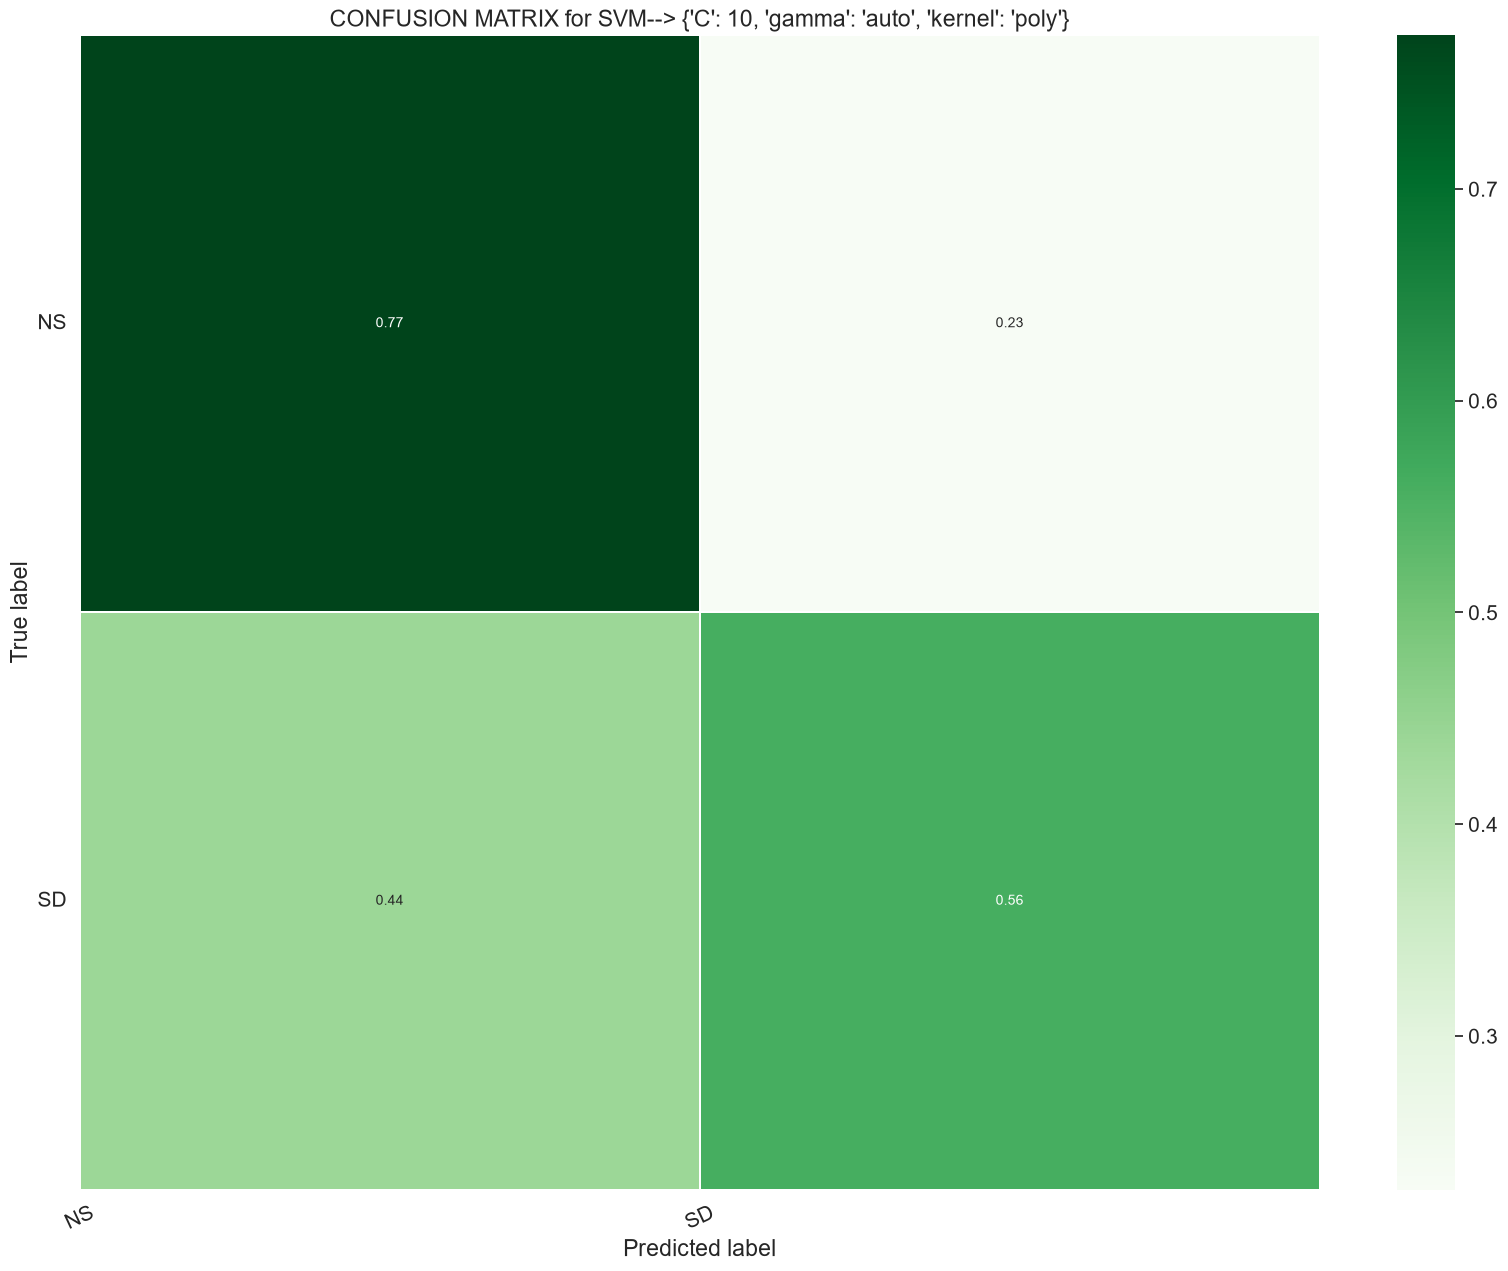

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming y_test and grid_predictions are defined above
matrix = confusion_matrix(y_true=y_test, y_pred=grid_predictions)
matrix = matrix * 100
matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(20,15))
sns.set(font_scale=1.4)

# Plotting the heatmap
sns.heatmap(matrix, annot=True, annot_kws={'size':10}, cmap=plt.cm.Greens, linewidths=0.2)

y_list = ['NS','SD']
class_names = y_list

# CORRECTED: 'np.arange' instead of 'np.arrange'
tick_marks = np.arange(len(class_names))
tick_marks2 = tick_marks + 0.5

plt.xticks(tick_marks, class_names, rotation=25)
plt.yticks(tick_marks2, class_names, rotation=0)

plt.xlabel('Predicted label')
# CORRECTED: plt.ylabel instead of plt.ylable, and 'label' instead of 'lable'
plt.ylabel('True label')

# CORRECTED: Formatted the title string properly so it doesn't crash
plt.title(f'CONFUSION MATRIX for SVM--> {grid.best_params_}')
plt.show()

In [28]:
from xgboost import XGBClassifier

In [29]:
XGB = XGBClassifier(
    n_estimators=300,             # Reduced from 1000
    learning_rate=0.05,           # Kept the same
    max_depth=4,                  # Reduced from 6
    subsample=0.8,                # Kept the same
    colsample_bytree=0.8,         # Kept the same
    objective='binary:logistic',  # CHANGED (Crucial)
    eval_metric='logloss',        # CHANGED (Crucial)
    tree_method='hist',           # CHANGED for speed
    random_state=42               # Added for reproducibility
)

In [30]:
XGB.fit(X_train_features, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
predictions = XGB.predict(X_test_features)

In [32]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[24 20]
 [12 29]]


Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.55      0.60        44
           1       0.59      0.71      0.64        41

    accuracy                           0.62        85
   macro avg       0.63      0.63      0.62        85
weighted avg       0.63      0.62      0.62        85



Accuracy: 0.6235294117647059


In [33]:
from sklearn.neighbors import KNeighborsClassifier

In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

In [35]:
knn.fit(X_train_features, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [36]:
predictions = knn.predict(X_test_features)

In [37]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[24 20]
 [22 19]]


Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.55      0.53        44
           1       0.49      0.46      0.47        41

    accuracy                           0.51        85
   macro avg       0.50      0.50      0.50        85
weighted avg       0.51      0.51      0.51        85



Accuracy: 0.5058823529411764


In [38]:
error_rate = []

for i in range(1,100):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_features,y_train)
    pred_i = knn.predict(X_test_features)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

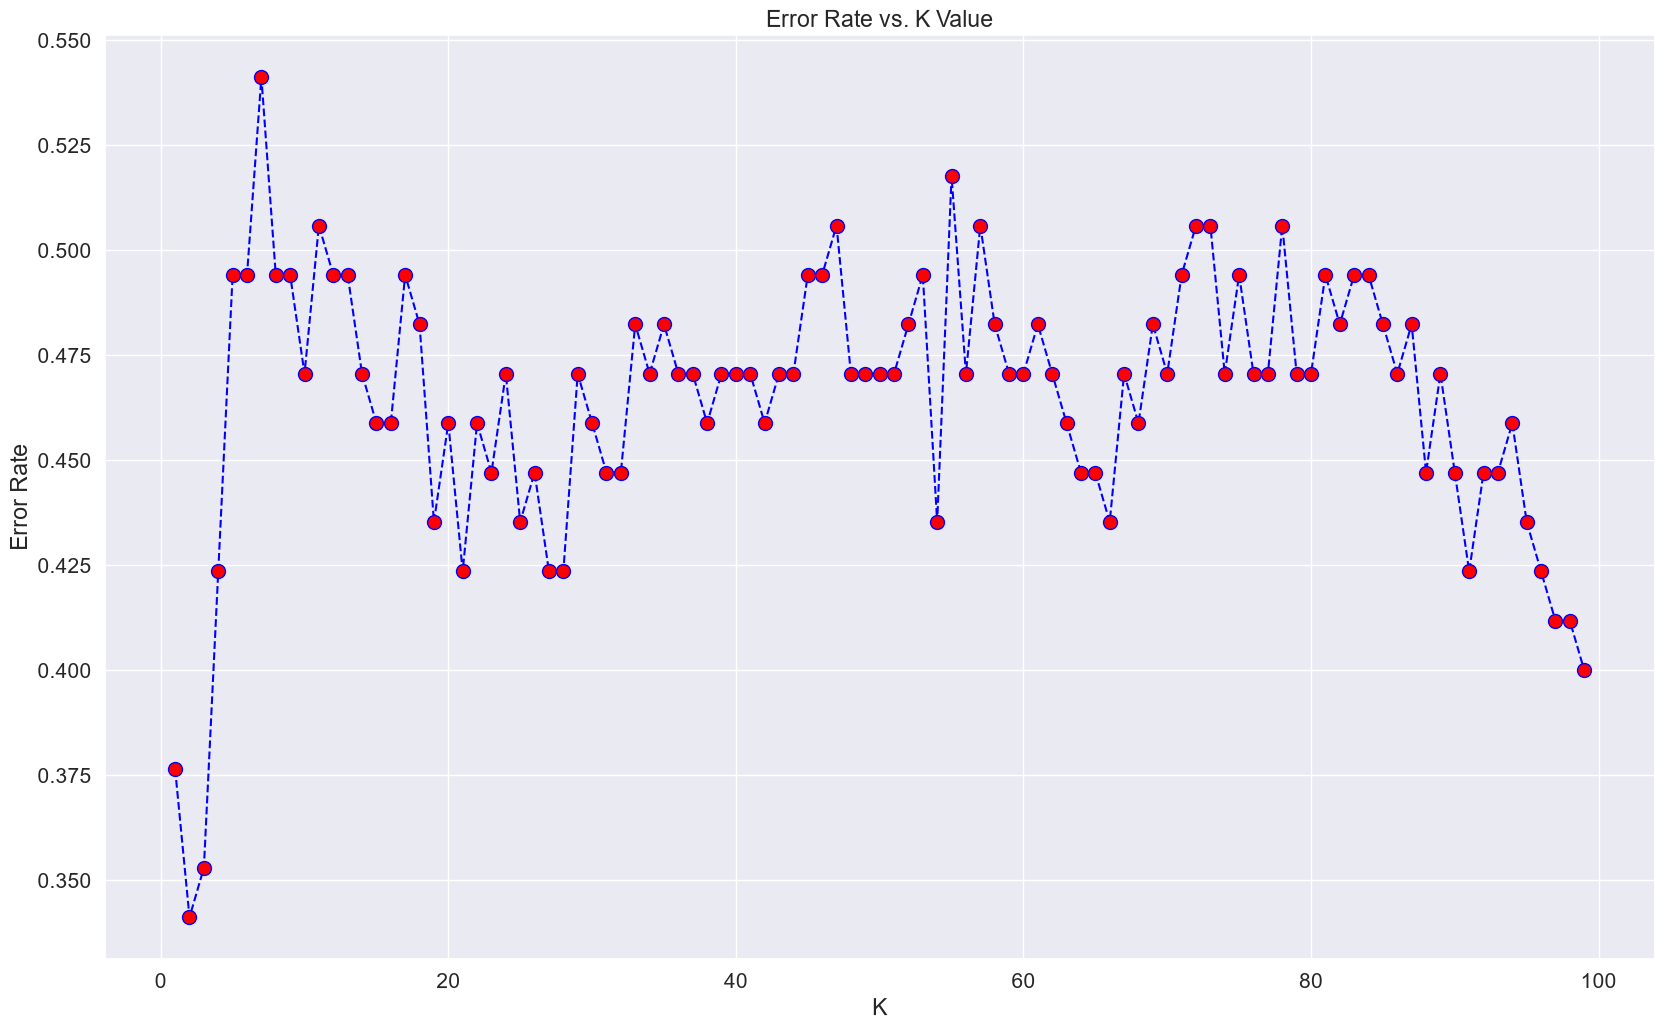

In [39]:
plt.figure(figsize=(20,12))
plt.plot(range(1,100),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [40]:
knn_new = KNeighborsClassifier(n_neighbors=1)

In [41]:
knn_new.fit(X_train_features, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [42]:
predictions = knn_new.predict(X_test_features)

In [43]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[22 22]
 [10 31]]


Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.50      0.58        44
           1       0.58      0.76      0.66        41

    accuracy                           0.62        85
   macro avg       0.64      0.63      0.62        85
weighted avg       0.64      0.62      0.62        85



Accuracy: 0.6235294117647059


### Leave One Subject Out Cross Validation

In [44]:
X_all=[]
y_all=[]

In [45]:
X_all = np.vstack((X_train_features, X_test_features))
y_all = np.concatenate((y_train, y_test))

print(f"Total shape of features: {X_all.shape}")
print(f"Total shape of labels: {y_all.shape}")

Total shape of features: (424, 854)
Total shape of labels: (424,)


In [46]:
groups_list = []
for i in range(1, 72):
    if i in [1,7,8,11,13,18,24,28,29,31,35,36,37,38,39,40,43,44,47,48,50,54,58,59,63,67,70,71]: 
        continue
    for j in range(1, 3):
        epochs_file = f'D:processed_epochs_60\\sub-{i:02d}_ses-{j}_epochs.fif'
        if os.path.exists(epochs_file):
            # preload=False makes this instantly read just the shape/metadata
            epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
            groups_list.extend([i] * len(epochs))

groups = np.array(groups_list)
print(f"Total features shape: {X_all.shape}")
print(f"Total labels shape: {y_all.shape}")
print(f"Total groups shape: {groups.shape}")

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1507585141.py:9: RuntimeWarning: This filename (D:processed_epochs_60\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1507585141.py:9: RuntimeWarning: This filename (D:processed_epochs_60\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1507585141.py:9: RuntimeWarning: This filename (D:processed_epochs_60\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, p

Total features shape: (424, 854)
Total labels shape: (424,)
Total groups shape: (424,)


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1507585141.py:9: RuntimeWarning: This filename (D:processed_epochs_60\sub-69_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_2568\1507585141.py:9: RuntimeWarning: This filename (D:processed_epochs_60\sub-69_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)


In [47]:
from sklearn.model_selection import LeaveOneGroupOut
logo = LeaveOneGroupOut()

In [48]:
y_true_all = []
y_pred_all = []
Accuracy_rf_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm(logo.split(X_all, y_all, groups=groups), total=n_splits):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    rf.fit(X_train_cv, y_train_cv)
    predictions = model.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(predictions[0])
    Accuracy = Accuracy_rf_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))
print(len(Accuracy_rf_1))

  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.7272727272727273

Accuracy: 0.6818181818181818

Accuracy: 0.6363636363636364

Accuracy: 0.5909090909090909

Accuracy: 0.5636363636363636

Accuracy: 0.6060606060606061

Accuracy: 0.5974025974025974

Accuracy: 0.5909090909090909

Accuracy: 0.6262626262626263

Accuracy: 0.6090909090909091

Accuracy: 0.5950413223140496

Accuracy: 0.5909090909090909

Accuracy: 0.5804195804195804

Accuracy: 0.564935064935065

Accuracy: 0.5757575757575758

Accuracy: 0.5738636363636364

Accuracy: 0.5668449197860963

Accuracy: 0.5656565656565656

Accuracy: 0.5598086124401914

Accuracy: 0.5681818181818182

Accuracy: 0.5627705627705628

Accuracy: 0.5743801652892562

Accuracy: 0.5691699604743083

Accuracy: 0.5643939393939394

Accuracy: 0.56

Accuracy: 0.5699300699300699

Accuracy: 0.5656565656565656

Accuracy: 0.5635179153094463

Accuracy: 0.5660377358490566

Accuracy: 0.5640243902439024

Accuracy: 0.5617647058823529

Accuracy: 0.5612535612535613

Accuracy: 0.5580110497237569

Accuracy: 0.557640750670

In [49]:
y_true_all = []
y_pred_all = []
Accuracy_SVC_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm(logo.split(X_all, y_all, groups=groups), total=n_splits):
    from sklearn.svm import SVC
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    svc = SVC(C= 10, gamma = 'auto', kernel= 'poly')
    svc.fit(X_train_cv, y_train_cv)
    predictions = svc.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(predictions[0])
    Accuracy = Accuracy_SVC_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))
print(len(Accuracy_SVC_1))

  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.45454545454545453

Accuracy: 0.6363636363636364

Accuracy: 0.7575757575757576

Accuracy: 0.7272727272727273

Accuracy: 0.6545454545454545

Accuracy: 0.6515151515151515

Accuracy: 0.6103896103896104

Accuracy: 0.6022727272727273

Accuracy: 0.6161616161616161

Accuracy: 0.5909090909090909

Accuracy: 0.5867768595041323

Accuracy: 0.5757575757575758

Accuracy: 0.5664335664335665

Accuracy: 0.551948051948052

Accuracy: 0.5575757575757576

Accuracy: 0.5511363636363636

Accuracy: 0.5294117647058824

Accuracy: 0.5202020202020202

Accuracy: 0.5358851674641149

Accuracy: 0.5318181818181819

Accuracy: 0.5281385281385281

Accuracy: 0.5454545454545454

Accuracy: 0.5335968379446641

Accuracy: 0.5378787878787878

Accuracy: 0.5345454545454545

Accuracy: 0.5384615384615384

Accuracy: 0.5387205387205387

Accuracy: 0.5309446254071661

Accuracy: 0.5345911949685535

Accuracy: 0.5274390243902439

Accuracy: 0.5323529411764706

Accuracy: 0.5327635327635327

Accuracy: 0.5386740331491713

Accuracy:

In [50]:
y_true_all = []
y_pred_all = []
Accuracy_XGB_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm(logo.split(X_all, y_all, groups=groups), total=n_splits):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    XGB.fit(X_train_cv, y_train_cv)
    predictions = XGB.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(predictions[0])
    Accuracy = Accuracy_XGB_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))
print(len(Accuracy_XGB_1))

  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.5454545454545454

Accuracy: 0.6363636363636364

Accuracy: 0.6363636363636364

Accuracy: 0.6136363636363636

Accuracy: 0.6545454545454545

Accuracy: 0.6666666666666666

Accuracy: 0.6493506493506493

Accuracy: 0.6363636363636364

Accuracy: 0.6666666666666666

Accuracy: 0.6454545454545455

Accuracy: 0.628099173553719

Accuracy: 0.6136363636363636

Accuracy: 0.6083916083916084

Accuracy: 0.6103896103896104

Accuracy: 0.6363636363636364

Accuracy: 0.6306818181818182

Accuracy: 0.6363636363636364

Accuracy: 0.6363636363636364

Accuracy: 0.631578947368421

Accuracy: 0.6454545454545455

Accuracy: 0.658008658008658

Accuracy: 0.6735537190082644

Accuracy: 0.6758893280632411

Accuracy: 0.6666666666666666

Accuracy: 0.6690909090909091

Accuracy: 0.6713286713286714

Accuracy: 0.6632996632996633

Accuracy: 0.6514657980456026

Accuracy: 0.660377358490566

Accuracy: 0.6524390243902439

Accuracy: 0.6558823529411765

Accuracy: 0.6552706552706553

Accuracy: 0.6574585635359116

Accuracy: 0.6

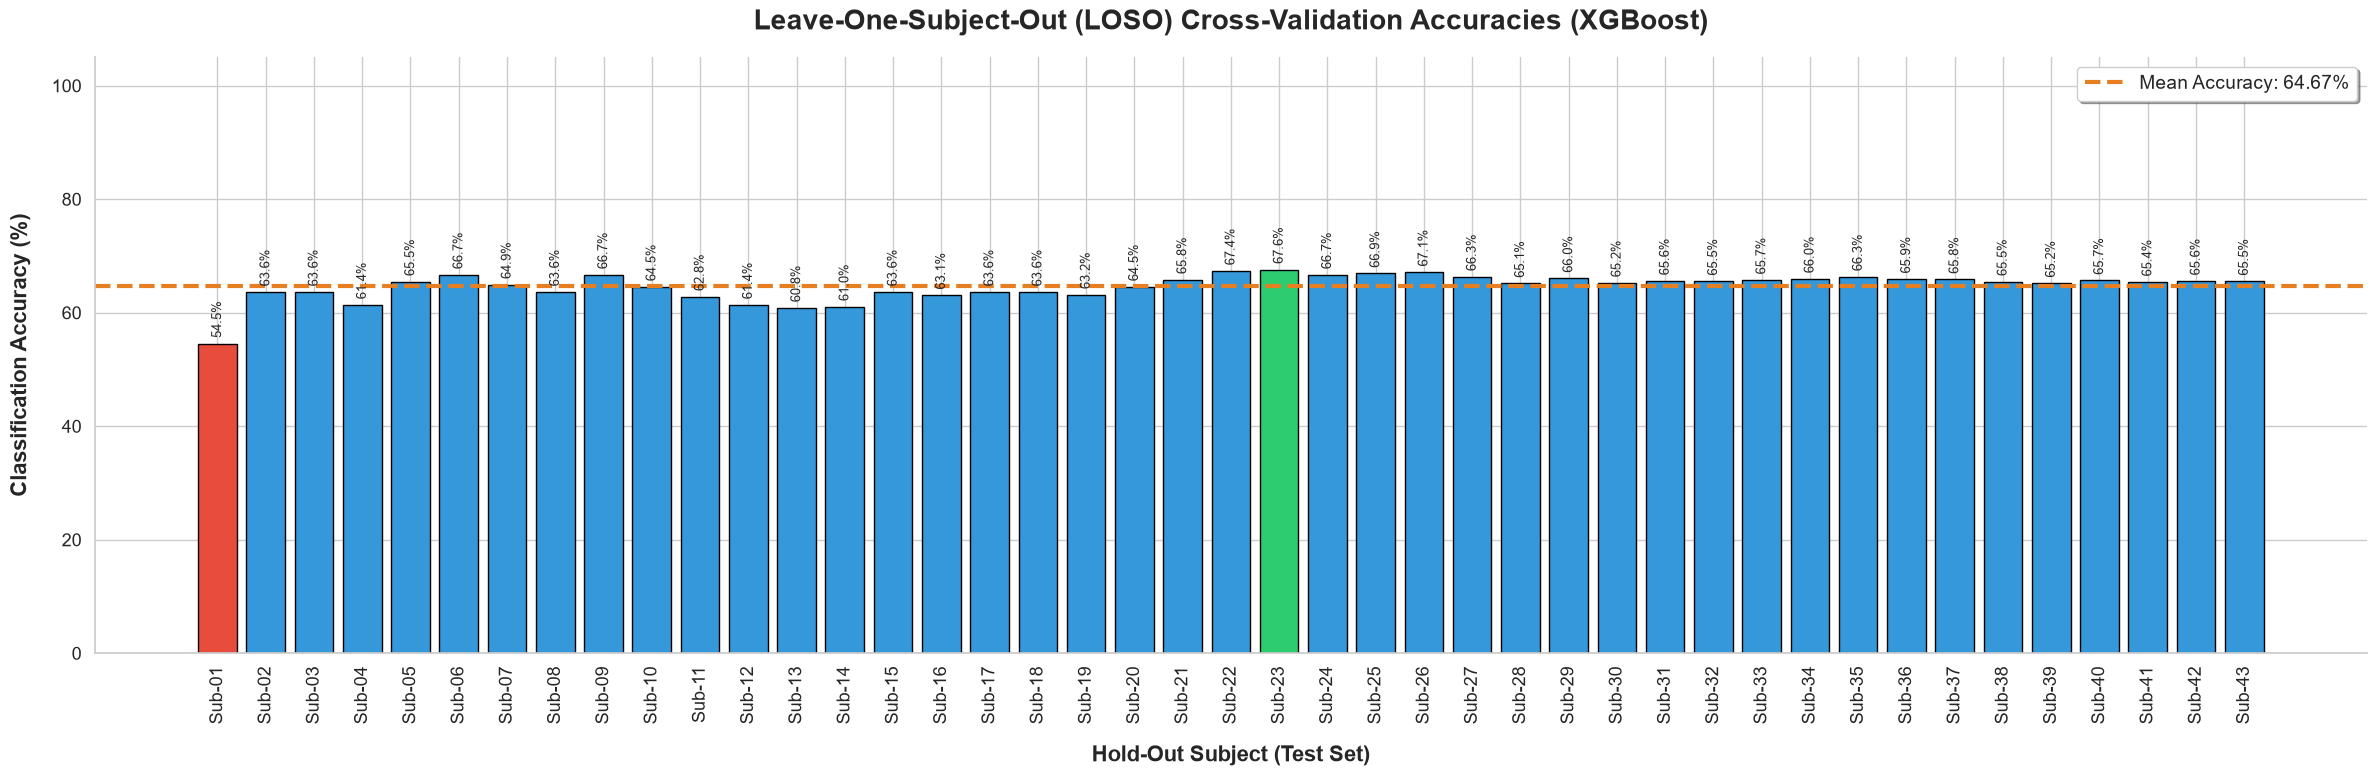

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming 'Accuracy_XGB_1' is the list containing your LOSO accuracies
# Example format: Accuracy_XGB_1 = [0.65, 0.72, 0.45, 0.81, ...]
accuracies = np.array(Accuracy_XGB_1) * 100 # Convert decimal to percentage

# Generate Subject IDs (e.g., Sub-01, Sub-02) based on the length of the list
subject_ids = [f'Sub-{i+1:02d}' for i in range(len(accuracies))]

# Calculate statistics
mean_acc = np.mean(accuracies)
max_acc = np.max(accuracies)
min_acc = np.min(accuracies)

plt.figure(figsize=(24, 8))
sns.set(style="whitegrid", font_scale=1.2)

# Create a color palette: standard blue, but highlight the best and worst in different colors
colors = ['#2ecc71' if acc == max_acc else '#e74c3c' if acc == min_acc else '#3498db' for acc in accuracies]

# Create the bar plot
bars = plt.bar(subject_ids, accuracies, color=colors, edgecolor='black', linewidth=1)

# Add a horizontal line for the Mean Accuracy
plt.axhline(y=mean_acc, color='#e67e22', linestyle='--', linewidth=3, label=f'Mean Accuracy: {mean_acc:.2f}%')

# Add the exact percentage text on top of every single bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=9, rotation=90)

# Formatting the plot
plt.title('Leave-One-Subject-Out (LOSO) Cross-Validation Accuracies (XGBoost)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hold-Out Subject (Test Set)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylim(0, 105) # Set Y-axis slightly above 100 to fit the text labels
plt.xticks(rotation=90) # Rotate subject IDs so they don't overlap

# Add a legend
plt.legend(loc='upper right', fontsize=14, frameon=True, shadow=True)

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

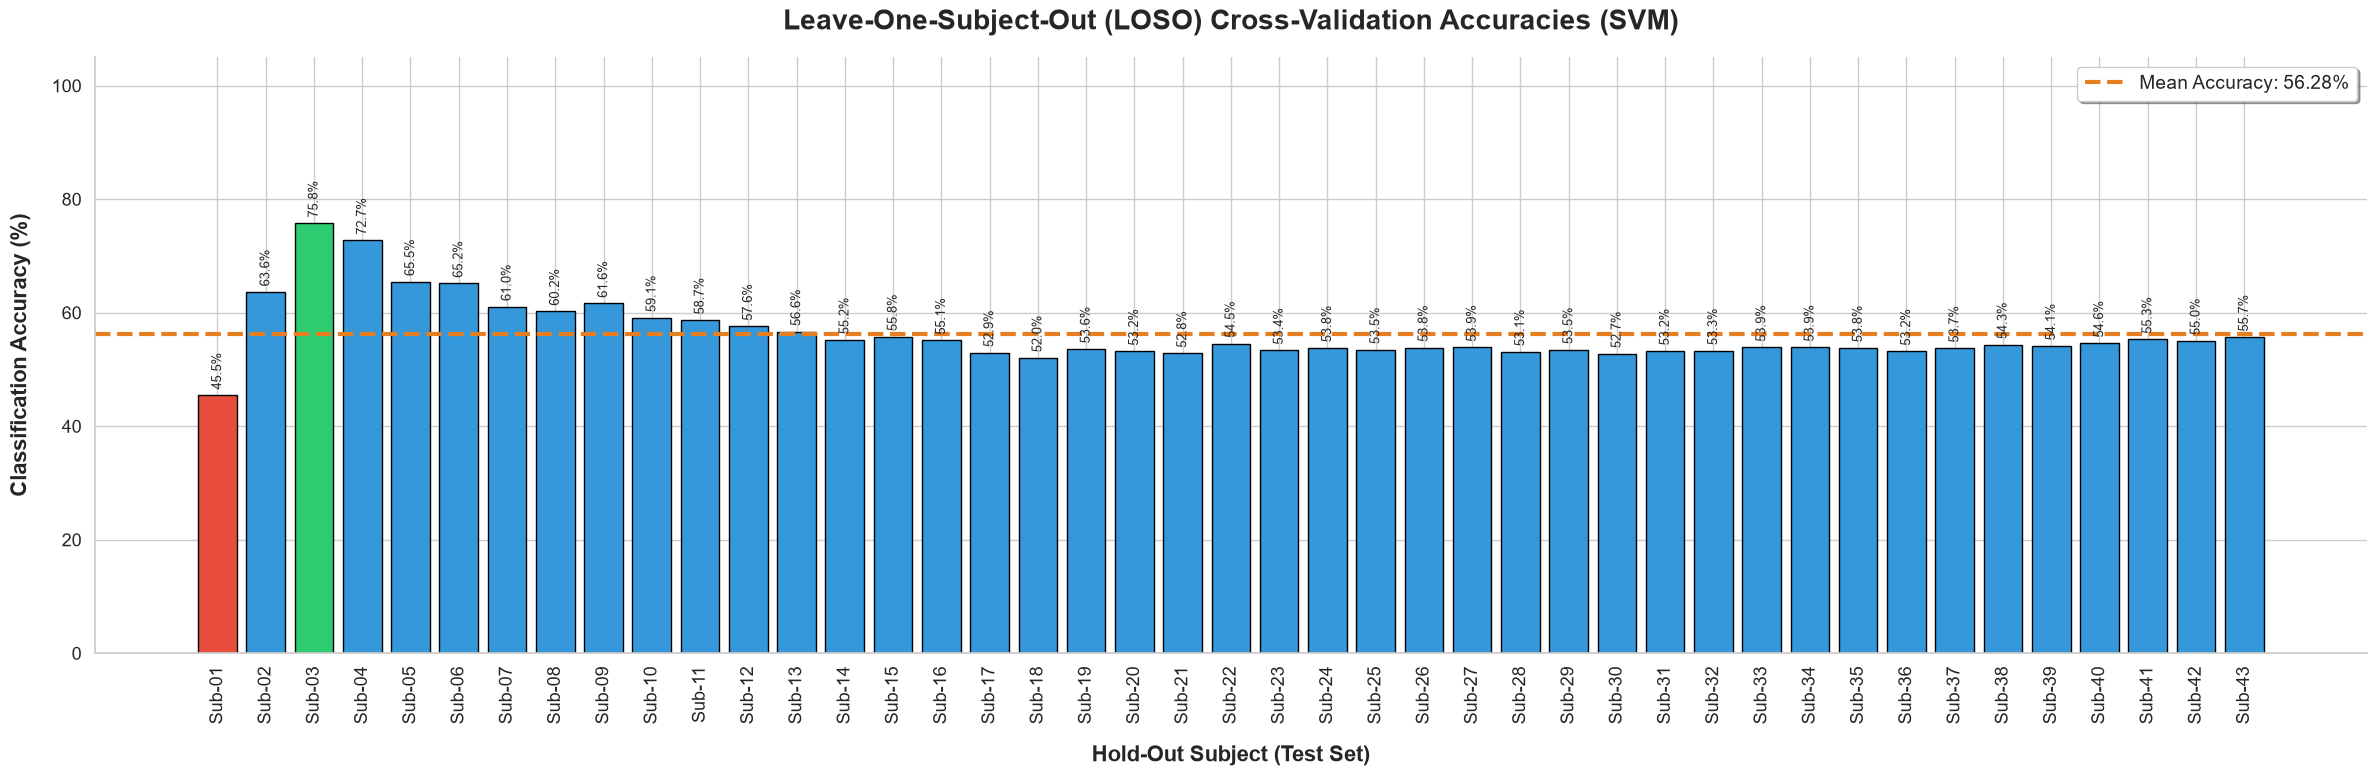

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming 'Accuracy_XGB_1' is the list containing your LOSO accuracies
# Example format: Accuracy_XGB_1 = [0.65, 0.72, 0.45, 0.81, ...]
accuracies = np.array(Accuracy_SVC_1) * 100 # Convert decimal to percentage

# Generate Subject IDs (e.g., Sub-01, Sub-02) based on the length of the list
subject_ids = [f'Sub-{i+1:02d}' for i in range(len(accuracies))]

# Calculate statistics
mean_acc = np.mean(accuracies)
max_acc = np.max(accuracies)
min_acc = np.min(accuracies)

plt.figure(figsize=(24, 8))
sns.set(style="whitegrid", font_scale=1.2)

# Create a color palette: standard blue, but highlight the best and worst in different colors
colors = ['#2ecc71' if acc == max_acc else '#e74c3c' if acc == min_acc else '#3498db' for acc in accuracies]

# Create the bar plot
bars = plt.bar(subject_ids, accuracies, color=colors, edgecolor='black', linewidth=1)

# Add a horizontal line for the Mean Accuracy
plt.axhline(y=mean_acc, color='#e67e22', linestyle='--', linewidth=3, label=f'Mean Accuracy: {mean_acc:.2f}%')

# Add the exact percentage text on top of every single bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=9, rotation=90)

# Formatting the plot
plt.title('Leave-One-Subject-Out (LOSO) Cross-Validation Accuracies (SVM)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hold-Out Subject (Test Set)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylim(0, 105) # Set Y-axis slightly above 100 to fit the text labels
plt.xticks(rotation=90) # Rotate subject IDs so they don't overlap

# Add a legend
plt.legend(loc='upper right', fontsize=14, frameon=True, shadow=True)

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

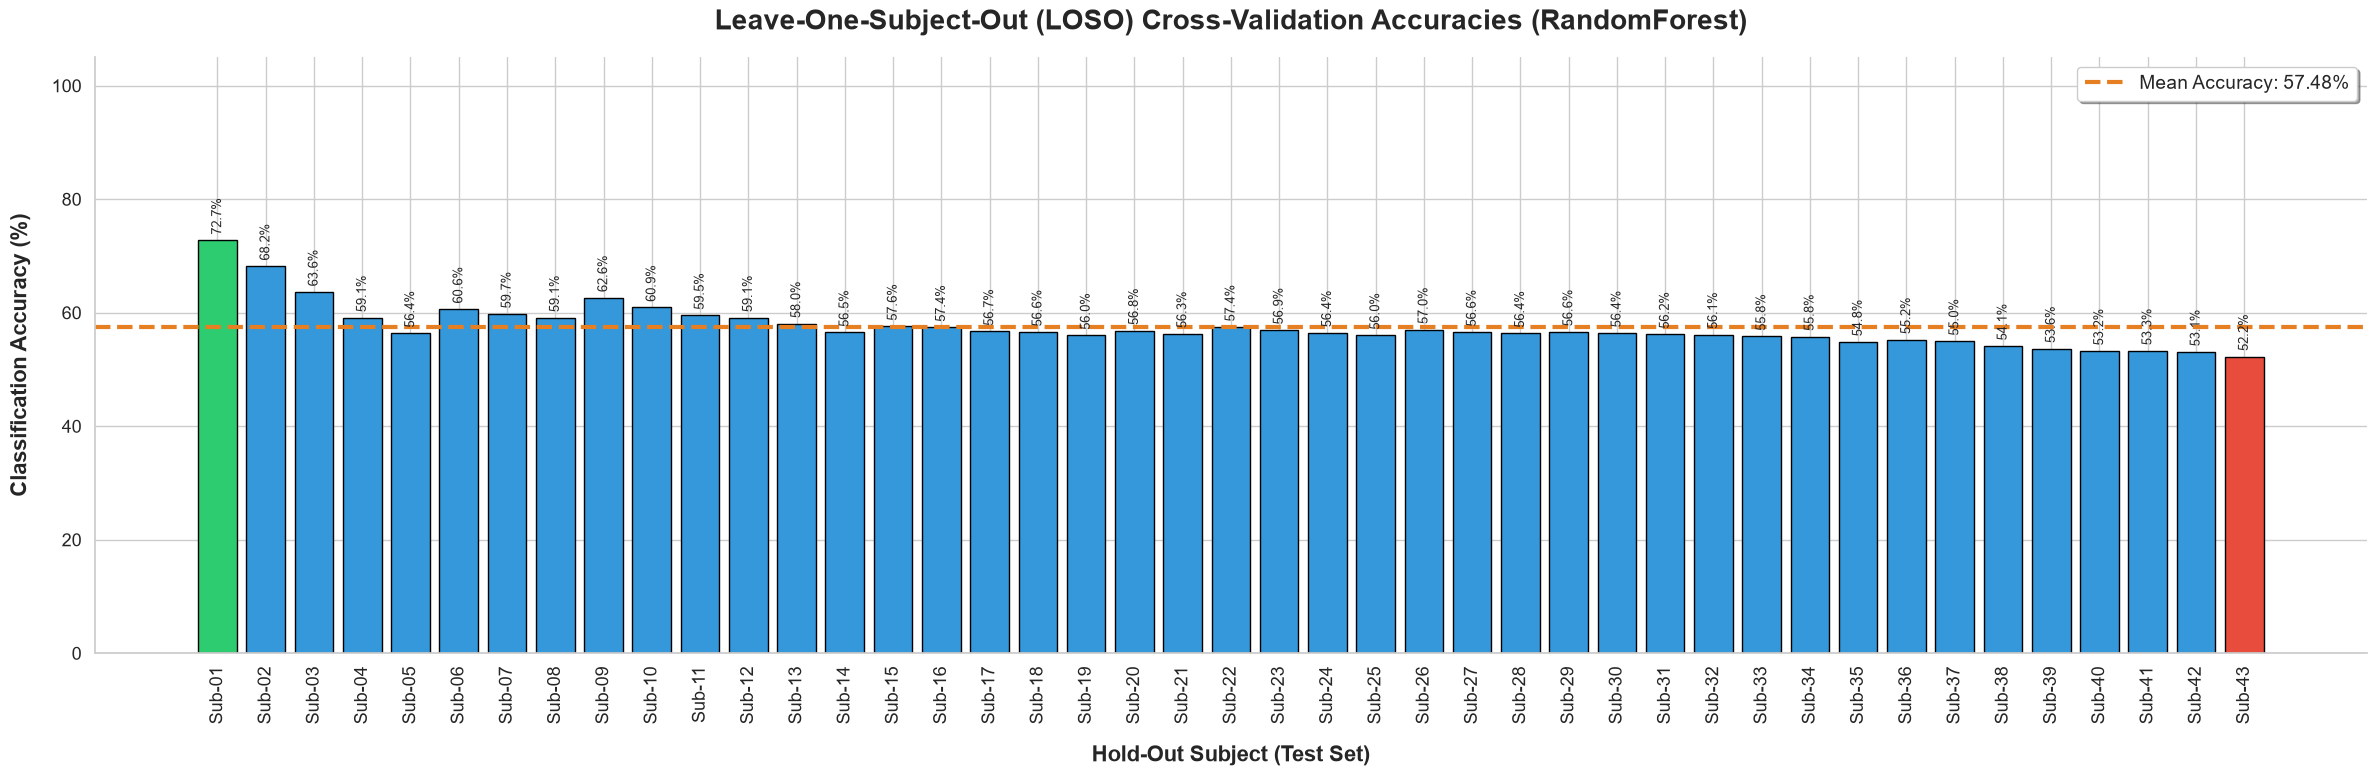

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming 'Accuracy_XGB_1' is the list containing your LOSO accuracies
# Example format: Accuracy_XGB_1 = [0.65, 0.72, 0.45, 0.81, ...]
accuracies = np.array(Accuracy_rf_1) * 100 # Convert decimal to percentage

# Generate Subject IDs (e.g., Sub-01, Sub-02) based on the length of the list
subject_ids = [f'Sub-{i+1:02d}' for i in range(len(accuracies))]

# Calculate statistics
mean_acc = np.mean(accuracies)
max_acc = np.max(accuracies)
min_acc = np.min(accuracies)

plt.figure(figsize=(24, 8))
sns.set(style="whitegrid", font_scale=1.2)

# Create a color palette: standard blue, but highlight the best and worst in different colors
colors = ['#2ecc71' if acc == max_acc else '#e74c3c' if acc == min_acc else '#3498db' for acc in accuracies]

# Create the bar plot
bars = plt.bar(subject_ids, accuracies, color=colors, edgecolor='black', linewidth=1)

# Add a horizontal line for the Mean Accuracy
plt.axhline(y=mean_acc, color='#e67e22', linestyle='--', linewidth=3, label=f'Mean Accuracy: {mean_acc:.2f}%')

# Add the exact percentage text on top of every single bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=9, rotation=90)

# Formatting the plot
plt.title('Leave-One-Subject-Out (LOSO) Cross-Validation Accuracies (RandomForest)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hold-Out Subject (Test Set)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylim(0, 105) # Set Y-axis slightly above 100 to fit the text labels
plt.xticks(rotation=90) # Rotate subject IDs so they don't overlap

# Add a legend
plt.legend(loc='upper right', fontsize=14, frameon=True, shadow=True)

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()